In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from matplotlib import pyplot as plt

In [2]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z):
        h = F.relu(self.fc2(z))
        x_recon = torch.sigmoid(self.fc3(h))
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar


In [3]:
def vae_loss(recon_x, x, mu, logvar):
    # Reconstruction loss
    bce = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # KL divergence
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return bce + kld, bce, kld


In [4]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = VAE().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

cpu


In [6]:
num_epochs = 30
train_losses = []
bce_losses = []
kld_losses = []

In [7]:
train_losses = []
bce_losses = []
kld_losses = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    running_bce = 0
    running_kld = 0

    for x, _ in train_loader:

        x = x.view(-1, 784).to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(x)

        loss, bce, kld = vae_loss(recon, x, mu, logvar)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        running_bce += bce.item()
        running_kld += kld.item()

    train_losses.append(running_loss / len(train_loader))
    bce_losses.append(running_bce / len(train_loader))
    kld_losses.append(running_kld / len(train_loader))

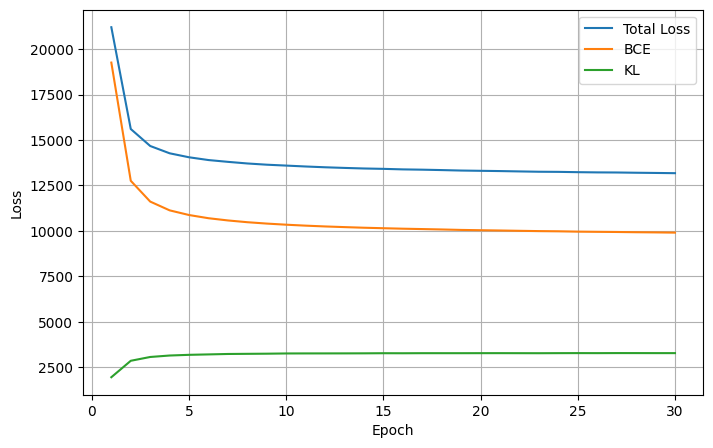

In [8]:
plt.figure(figsize=(8,5))

plt.plot(range(1, num_epochs+1), train_losses, label="Total Loss")
plt.plot(range(1, num_epochs+1), bce_losses, label="BCE")
plt.plot(range(1, num_epochs+1), kld_losses, label="KL")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [9]:
model.eval()

with torch.no_grad():

    images, _ = next(iter(test_loader))

    images = images.view(-1,784).to(device)

    recon, _, _ = model(images)

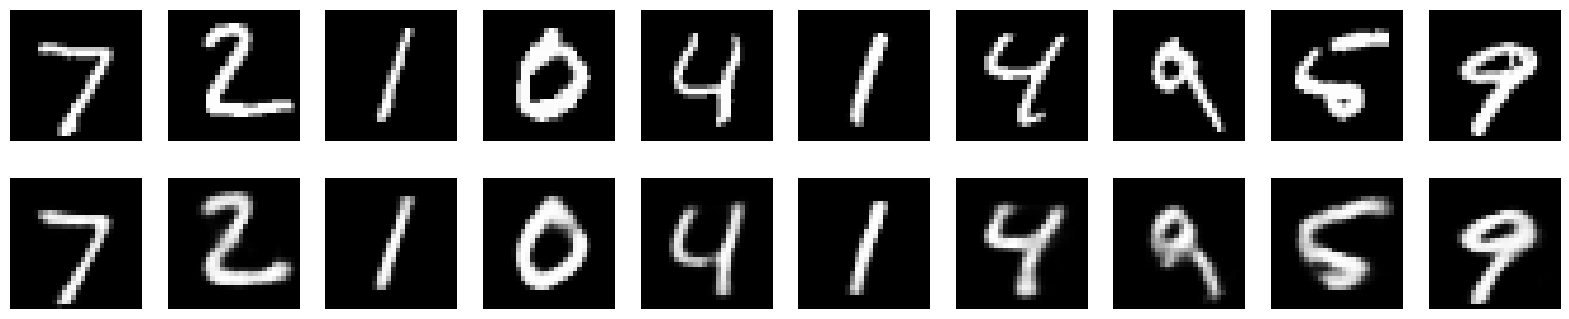

In [10]:
n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    # تصویر واقعی
    plt.subplot(2,n,i+1)
    plt.imshow(images[i].cpu().view(28,28), cmap="gray")
    plt.axis("off")

    # تصویر بازسازی شده
    plt.subplot(2,n,i+n+1)
    plt.imshow(recon[i].cpu().view(28,28), cmap="gray")
    plt.axis("off")

plt.show()

In [11]:
model.eval()

with torch.no_grad():

    z = torch.randn(10,20).to(device)

    generated = model.decode(z)

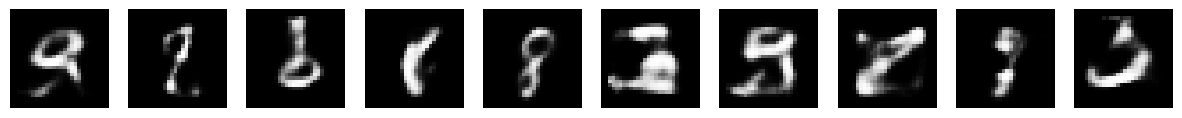

In [12]:
plt.figure(figsize=(15,2))

for i in range(10):

    plt.subplot(1,10,i+1)

    plt.imshow(generated[i].cpu().view(28,28), cmap="gray")

    plt.axis("off")

plt.show()

In [13]:
latent = []

labels = []

model.eval()

with torch.no_grad():

    for x,y in test_loader:

        x = x.view(-1,784).to(device)

        mu, logvar = model.encode(x)

        latent.append(mu.cpu())

        labels.append(y)

In [14]:
latent = torch.cat(latent)

labels = torch.cat(labels)

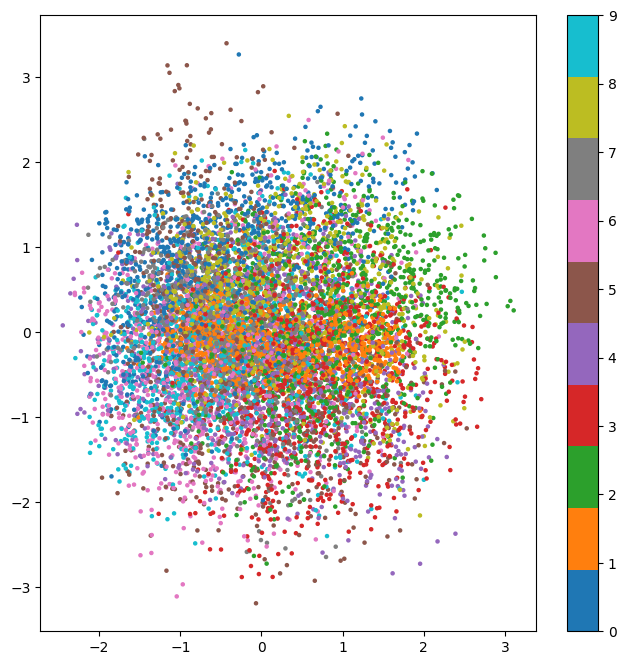

In [15]:
plt.figure(figsize=(8,8))

plt.scatter(latent[:,0],
            latent[:,1],
            c=labels,
            s=5,
            cmap="tab10")

plt.colorbar()

plt.show()

In [16]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2)

latent_2d = tsne.fit_transform(latent)

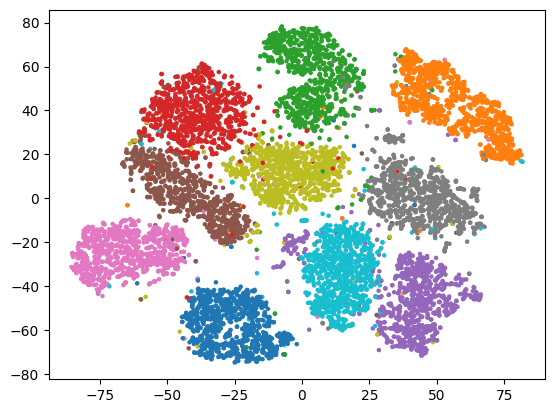

In [17]:
plt.scatter(latent_2d[:,0],
            latent_2d[:,1],
            c=labels,
            s=5,
            cmap="tab10")

In [18]:
# def weight_reset(m):
#     if hasattr(m, 'reset_parameters'):
#         m.reset_parameters()
# model.apply(weight_reset)
